In [1]:
from sympy import symbols, cos, sin, Matrix, pprint

# Define symbols
l1, l2, l3, phi1, phi2, x2, x3, y2, y3 = symbols('l1 l2 l3 phi1 phi2 x2 x3 y2 y3')

# Define the matrix A
A = Matrix([
    [-1/2*l1*sin(phi1), -1, 0, -1/2*l2*sin(phi2), 0],
    [1/2*l1*cos(phi1), 0, -1, -1/2*l2*cos(phi2), 0],
    [0, 0, 0, 1, -1],
    [0, cos(phi2), -sin(phi2), -(x2 - x3)*sin(phi2) + (y2 - y3)*cos(phi2) + l3, -l3],
    [0, 0, 0, 0, 1]
])

# Calculate the inverse
B = A.inv()

# Print the symbolic inverse matrix
pprint(B)


⎡                 -2.0⋅cos(φ₂)                                      2.0⋅sin(φ₂
⎢───────────────────────────────────────────────  ────────────────────────────
⎢1.0⋅l₁⋅sin(φ₁)⋅cos(φ₂) + 1.0⋅l₁⋅sin(φ₂)⋅cos(φ₁)  1.0⋅l₁⋅sin(φ₁)⋅cos(φ₂) + 1.0
⎢                                                                             
⎢                                                                             
⎢             -1.0⋅sin(φ₂)⋅cos(φ₁)                             -1.0⋅sin(φ₁)⋅si
⎢   ─────────────────────────────────────────        ─────────────────────────
⎢   1.0⋅sin(φ₁)⋅cos(φ₂) + 1.0⋅sin(φ₂)⋅cos(φ₁)        1.0⋅sin(φ₁)⋅cos(φ₂) + 1.0
⎢                                                                             
⎢                                                                             
⎢             -1.0⋅cos(φ₁)⋅cos(φ₂)                             -1.0⋅sin(φ₁)⋅co
⎢   ─────────────────────────────────────────        ─────────────────────────
⎢   1.0⋅sin(φ₁)⋅cos(φ₂) + 1.0⋅sin(φ₂)⋅cos(φ₁)       

In [2]:
from sympy import symbols, Function, diff, pprint, Eq, latex

# Define symbolic variables
t = symbols('t')
l1, l2, l3, phi1, phi2, x2, x3, y2, y3, omega = symbols('l1 l2 l3 phi1 phi2 x2 x3 y2 y3 omega')
phi1, x2, y2, phi2, phi3 = symbols('phi1 x2 y2 phi2 phi3', cls=Function)

# Define the vector q as a function of time
q = Matrix([phi1(t), x2(t), y2(t), phi2(t), phi3(t)])

# Calculate the time derivative of q
q_dot = q.diff(t)

# Print the vectors
print("Vector q:")
pprint(q)

# print("\nTime derivative of vector q:")
# pprint(q_dot)


Vector q:
⎡φ₁(t)⎤
⎢     ⎥
⎢x₂(t)⎥
⎢     ⎥
⎢y₂(t)⎥
⎢     ⎥
⎢φ₂(t)⎥
⎢     ⎥
⎣φ₃(t)⎦


In [3]:
# Define the vector C
C = Matrix([0, 0, 0, 0, -omega])

# Calculate B * q_dot
B_q_dot = B * q_dot

# Set up equations B * q_dot = C
equations = [Eq(B_q_dot[i], C[i]) for i in range(len(B_q_dot))]

# Print the resulting equations
print("Equations from B * q_dot = C:")
for equation in equations:
    print(latex(equation))

Equations from B * q_dot = C:
\frac{\left(- 2.0 x_{2} \sin{\left(\phi_{2} \right)} + 2.0 x_{3} \sin{\left(\phi_{2} \right)} + 2.0 y_{2} \cos{\left(\phi_{2} \right)} - 2.0 y_{3} \cos{\left(\phi_{2} \right)}\right) \frac{d}{d t} \phi_{3}{\left(t \right)}}{1.0 l_{1} \sin{\left(\phi_{1} \right)} \cos{\left(\phi_{2} \right)} + 1.0 l_{1} \sin{\left(\phi_{2} \right)} \cos{\left(\phi_{1} \right)}} + \frac{\left(2.0 l_{3} - 2.0 x_{2} \sin{\left(\phi_{2} \right)} + 2.0 x_{3} \sin{\left(\phi_{2} \right)} + 2.0 y_{2} \cos{\left(\phi_{2} \right)} - 2.0 y_{3} \cos{\left(\phi_{2} \right)}\right) \frac{d}{d t} y_{2}{\left(t \right)}}{1.0 l_{1} \sin{\left(\phi_{1} \right)} \cos{\left(\phi_{2} \right)} + 1.0 l_{1} \sin{\left(\phi_{2} \right)} \cos{\left(\phi_{1} \right)}} + \frac{2.0 \sin{\left(\phi_{2} \right)} \frac{d}{d t} x_{2}{\left(t \right)}}{1.0 l_{1} \sin{\left(\phi_{1} \right)} \cos{\left(\phi_{2} \right)} + 1.0 l_{1} \sin{\left(\phi_{2} \right)} \cos{\left(\phi_{1} \right)}} - \frac{2.0 \cos{

In [4]:
from sympy import symbols, Function, Eq, pprint, latex, simplify, pi, Matrix

# Define symbolic variables
l1, l2, l3, phi1, phi2, phi3, omega = symbols('l1 l2 l3 phi1 phi2 phi3 omega')
t = symbols('t')

# Define functions for x2, y2, and x3 (replace with your actual expressions)
x2 = Function('x2')(t)
y2 = Function('y2')(t)
x3 = Function('x3')(t)

# Define the vector q as a function of time
q = Matrix([phi1, x2, y2, phi2, phi3])

# Substitute specific values and relations
q_dot = q.diff(t)
q_dot = q_dot.subs({phi3: phi2 - pi/2, x3: 50, y3: 50, l1: 100, l2: 200, l3: 25})

# Calculate B * q_dot
B_q_dot = B * q_dot

# Set up equations B * q_dot = C
C = Matrix([0, 0, 0, 0, -omega])
equations = [Eq(B_q_dot[i], C[i]) for i in range(len(B_q_dot))]

# Simplify equations
simplified_equations = [simplify(equation) for equation in equations]

# Print the resulting simplified equations in LaTeX form
print("Simplified Equations from B * q_dot = C:")
for equation in simplified_equations:
    print(latex(equation))


Simplified Equations from B * q_dot = C:
\frac{2.0 \left(\left(l_{3} - x_{2} \sin{\left(\phi_{2} \right)} + x_{3} \sin{\left(\phi_{2} \right)} + y_{2} \cos{\left(\phi_{2} \right)} - y_{3} \cos{\left(\phi_{2} \right)}\right) \frac{d}{d t} y_{2}{\left(t \right)} + \sin{\left(\phi_{2} \right)} \frac{d}{d t} x_{2}{\left(t \right)}\right)}{l_{1} \sin{\left(\phi_{1} + \phi_{2} \right)}} = 0
\frac{1.0 \left(- \left(0.5 l_{2} \sin{\left(\phi_{2} \right)} \sin{\left(\phi_{1} + \phi_{2} \right)} + 1.0 l_{3} \sin{\left(\phi_{1} \right)} - 1.0 x_{2} \sin{\left(\phi_{1} \right)} \sin{\left(\phi_{2} \right)} + 1.0 x_{3} \sin{\left(\phi_{1} \right)} \sin{\left(\phi_{2} \right)} + 1.0 y_{2} \sin{\left(\phi_{1} \right)} \cos{\left(\phi_{2} \right)} - 1.0 y_{3} \sin{\left(\phi_{1} \right)} \cos{\left(\phi_{2} \right)}\right) \frac{d}{d t} y_{2}{\left(t \right)} - 1.0 \sin{\left(\phi_{1} \right)} \sin{\left(\phi_{2} \right)} \frac{d}{d t} x_{2}{\left(t \right)}\right)}{\sin{\left(\phi_{1} + \phi_{2} \rig

In [5]:
from sympy import symbols, Eq, solve, Function, cos, sin

# Define symbolic variables
phi1, phi3, omega, dot_phi1, dot_phi3, dot_x2, dot_y2 = symbols('phi1 phi3 omega dot_phi1 dot_phi3 dot_x2 dot_y2')

# Given equations
eq1 = Eq(dot_x2, -0.5 * 100 * sin(phi1) * dot_phi1 - 0.5 * 200 * cos(phi3) * omega)
eq2 = Eq(dot_y2, 0.5 * 100 * cos(phi1) * dot_phi1 + 0.5 * 200 * sin(phi3) * omega)
eq3 = Eq(omega, cos(phi3) * (dot_x2 - 50) + cos(phi3) * (dot_y2 - 50) + 25 / sin(phi3) * dot_phi3)

# Solve for dot_x2, dot_y2, and dot_phi1
solution = solve([eq1, eq2, eq3], (dot_x2, dot_y2, dot_phi1), dict=True)

# Extract the solutions
dot_x2_solution = solution[0][dot_x2].simplify()
dot_y2_solution = solution[0][dot_y2].simplify()
dot_phi1_solution = solution[0][dot_phi1].simplify()

# Print the solutions
print("dot_x2 =", dot_x2_solution)
print("dot_y2 =", dot_y2_solution)
print("dot_phi1 =", dot_phi1_solution)


dot_x2 = sqrt(2)*(50.0*dot_phi3*sin(phi1) + 50.0*omega*sin(phi1 - phi3) - 50.0*omega*sin(phi1 + 3*phi3) - 1.0*omega*cos(phi1 - phi3) + omega*cos(phi1 + phi3) - 50.0*cos(phi1 - 2*phi3) + 50.0*cos(phi1 + 2*phi3))/(-sin(phi1 - 2*phi3 + pi/4) + sin(phi1 + 2*phi3 + pi/4))
dot_y2 = sqrt(2)*(-50.0*dot_phi3*cos(phi1) - 51.0*omega*sin(phi1 - phi3) + omega*sin(phi1 + phi3) + 50.0*omega*sin(phi1 + 3*phi3) - 50.0*sin(phi1 - 2*phi3) + 50.0*sin(phi1 + 2*phi3))/(-sin(phi1 - 2*phi3 + pi/4) + sin(phi1 + 2*phi3 + pi/4))
dot_phi1 = 1.0*(-1.0*sqrt(2)*dot_phi3 + 4.04*sqrt(2)*omega*sin(phi3) - 4.0*omega*sin(phi3 + pi/4) + 2.0*omega*sin(3*phi3 + pi/4) + 2.0*omega*cos(phi3 + pi/4) + 2.0*sqrt(2)*sin(2*phi3))/(-sin(phi1 - 2*phi3 + pi/4) + sin(phi1 + 2*phi3 + pi/4))


## FFF

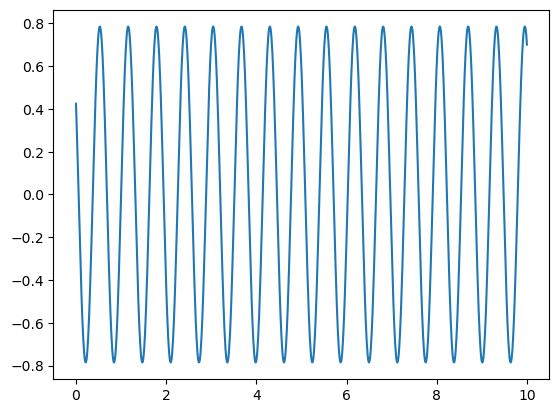

In [8]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 1000)
omega = 10
phi = np.pi /4 *np.cos(omega * t + 1)
plt.plot(t, phi)

In [9]:
0.8*180 / np.pi

45.83662361046586